# Visualización de datos

**Dataset a emplear**
dataset = household_power_consumption

2. Cargando el dataset

Este archivo usa ; como separador y tiene valores faltantes marcados como ?. Cópialo en tu notebook:

In [13]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Configuración visual global — ponla siempre al inicio
plt.rcParams['figure.figsize'] = (12, 5)
plt.rcParams['font.size'] = 11
sns.set_theme(style='whitegrid')

# Cargar el dataset
df = pd.read_csv(
    '../datasets/household_power_consumption.txt',
    sep=';',
    na_values='?',        # los '?' se convierten en NaN automáticamente
    low_memory=False
)

# Exploración inicial — siempre primero
print("-----------------------------")
print(df.shape)
print("-----------------------------")
print(df.head())
print("-----------------------------")
print(df.info())
print("-----------------------------")
print(df.isnull().sum())

-----------------------------
(2075259, 9)
-----------------------------
         Date      Time  Global_active_power  Global_reactive_power  Voltage  \
0  16/12/2006  17:24:00                4.216                  0.418   234.84   
1  16/12/2006  17:25:00                5.360                  0.436   233.63   
2  16/12/2006  17:26:00                5.374                  0.498   233.29   
3  16/12/2006  17:27:00                5.388                  0.502   233.74   
4  16/12/2006  17:28:00                3.666                  0.528   235.68   

   Global_intensity  Sub_metering_1  Sub_metering_2  Sub_metering_3  
0              18.4             0.0             1.0            17.0  
1              23.0             0.0             1.0            16.0  
2              23.0             0.0             2.0            17.0  
3              23.0             0.0             1.0            17.0  
4              15.8             0.0             1.0            17.0  
--------------------------

3. **Limpieza mínima necesaria**

In [14]:
# Combinar Date y Time en un solo datetime
df['Datetime'] = pd.to_datetime(df['Date'] + ' ' + df['Time'],format='%d/%m/%Y %H:%M:%S')

# Poner Datetime como índice — clave para series temporales
df.set_index('Datetime', inplace=True)
df.drop(columns=['Date', 'Time'], inplace=True)

# Eliminar filas con nulos en la columna principal
df.dropna(subset=['Global_active_power'], inplace=True)

# Convertir columnas a numérico por seguridad
cols = ['Global_active_power', 'Global_reactive_power',
        'Voltage', 'Global_intensity',
        'Sub_metering_1', 'Sub_metering_2', 'Sub_metering_3']
df[cols] = df[cols].apply(pd.to_numeric, errors='coerce')

print("-----------------------------")
print(df.shape)
print("-----------------------------")
print(df.head())

-----------------------------
(2049280, 7)
-----------------------------
                     Global_active_power  Global_reactive_power  Voltage  \
Datetime                                                                   
2006-12-16 17:24:00                4.216                  0.418   234.84   
2006-12-16 17:25:00                5.360                  0.436   233.63   
2006-12-16 17:26:00                5.374                  0.498   233.29   
2006-12-16 17:27:00                5.388                  0.502   233.74   
2006-12-16 17:28:00                3.666                  0.528   235.68   

                     Global_intensity  Sub_metering_1  Sub_metering_2  \
Datetime                                                                
2006-12-16 17:24:00              18.4             0.0             1.0   
2006-12-16 17:25:00              23.0             0.0             1.0   
2006-12-16 17:26:00              23.0             0.0             2.0   
2006-12-16 17:27:00          

4. Matplotlib — el motor de visualización

Matplotlib es la base de casi toda visualización en Python. Seaborn está construido sobre él. El concepto central es la figura con ejes:

Figure  →  el lienzo completo

Axes    →  el área donde vive un gráfico dentro del lienzo

Puedes tener múltiples Axes dentro de una Figure, lo que te permite comparar gráficos lado a lado.

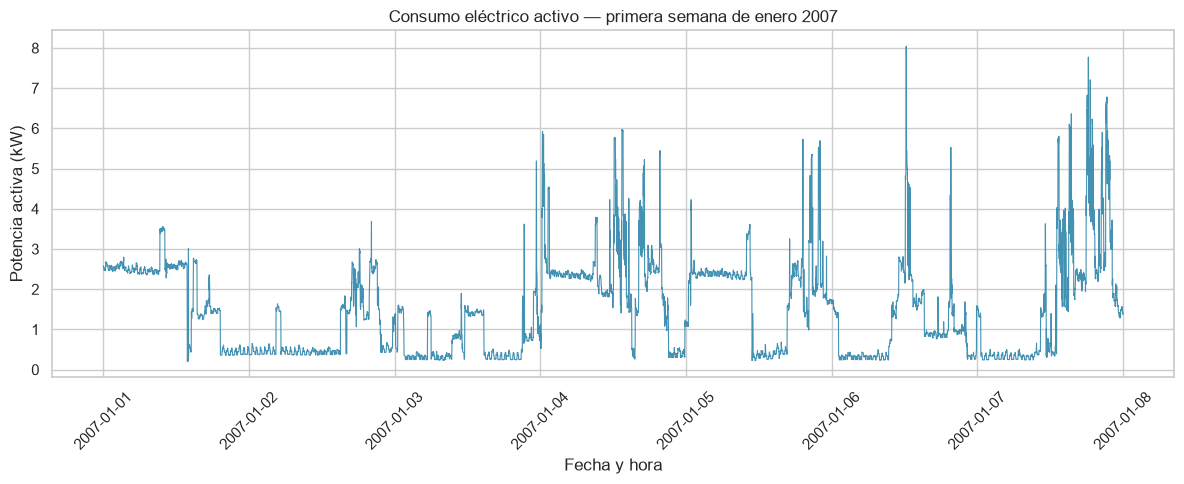

In [15]:
# Gráfico 1 — Consumo activo a lo largo del tiempo (muestra 1 semana)
semana = df['Global_active_power']['2007-01-01':'2007-01-07']

fig, ax = plt.subplots()
ax.plot(semana, color='#2E86AB', linewidth=0.8, alpha=0.9)
ax.set_title('Consumo eléctrico activo — primera semana de enero 2007')
ax.set_xlabel('Fecha y hora')
ax.set_ylabel('Potencia activa (kW)')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

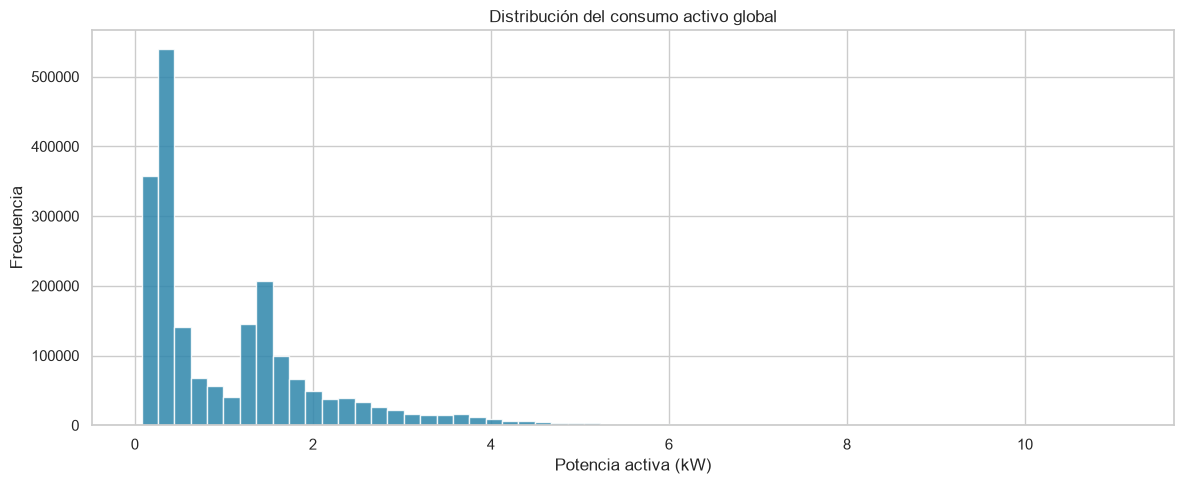

In [16]:
# Gráfico 2 — Distribución del consumo (histograma)
fig, ax = plt.subplots()
ax.hist(df['Global_active_power'].dropna(),
        bins=60, color='#2E86AB', edgecolor='white', alpha=0.85)
ax.set_title('Distribución del consumo activo global')
ax.set_xlabel('Potencia activa (kW)')
ax.set_ylabel('Frecuencia')
plt.tight_layout()
plt.show()

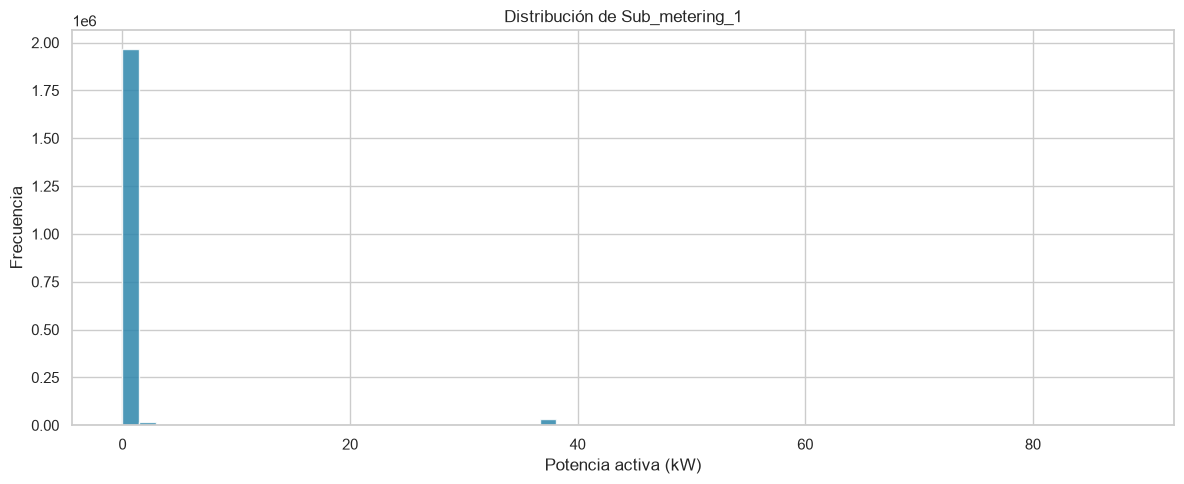

In [17]:
# Gráfico 2 — Distribución del consumo (histograma)
fig, ax = plt.subplots()
ax.hist(df['Sub_metering_1'].dropna(),
        bins=60, color='#2E86AB', edgecolor='white', alpha=0.85)
ax.set_title('Distribución de Sub_metering_1')
ax.set_xlabel('Potencia activa (kW)')
ax.set_ylabel('Frecuencia')
plt.tight_layout()
plt.show()

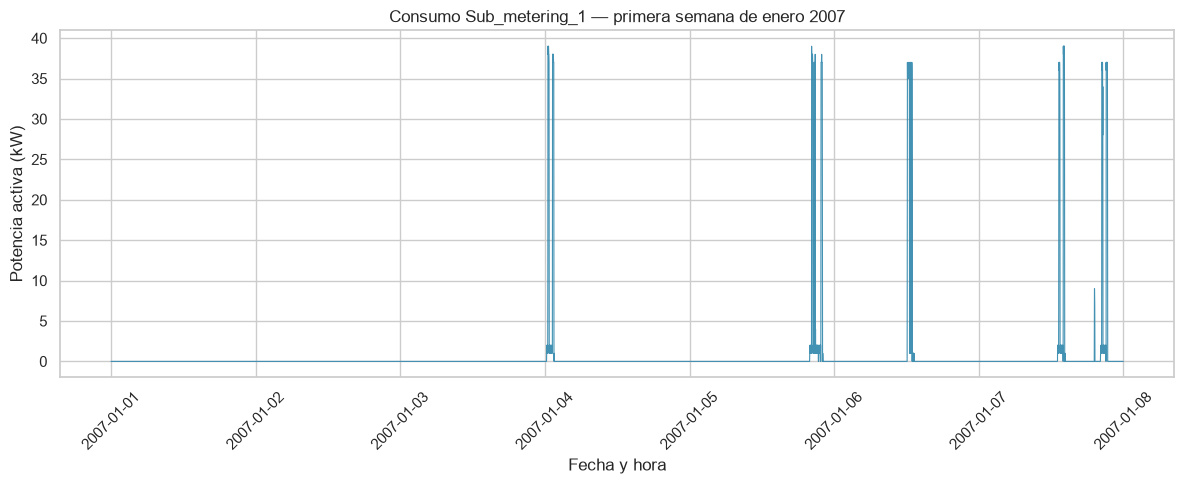

In [18]:
# Gráfico 1 — Consumo activo a lo largo del tiempo (muestra 1 semana)
semana = df['Sub_metering_1']['2007-01-01':'2007-01-07']

fig, ax = plt.subplots()
ax.plot(semana, color='#2E86AB', linewidth=0.8, alpha=0.9)
ax.set_title('Consumo Sub_metering_1 — primera semana de enero 2007')
ax.set_xlabel('Fecha y hora')
ax.set_ylabel('Potencia activa (kW)')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

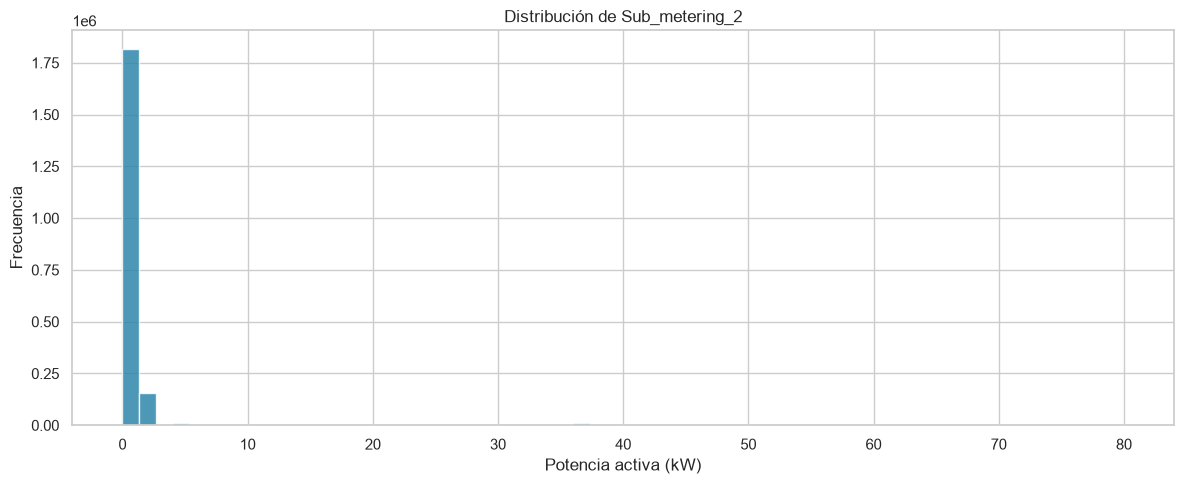

In [19]:
# Gráfico 2 — Distribución del consumo (histograma)
fig, ax = plt.subplots()
ax.hist(df['Sub_metering_2'].dropna(),
        bins=60, color='#2E86AB', edgecolor='white', alpha=0.85)
ax.set_title('Distribución de Sub_metering_2')
ax.set_xlabel('Potencia activa (kW)')
ax.set_ylabel('Frecuencia')
plt.tight_layout()
plt.show()

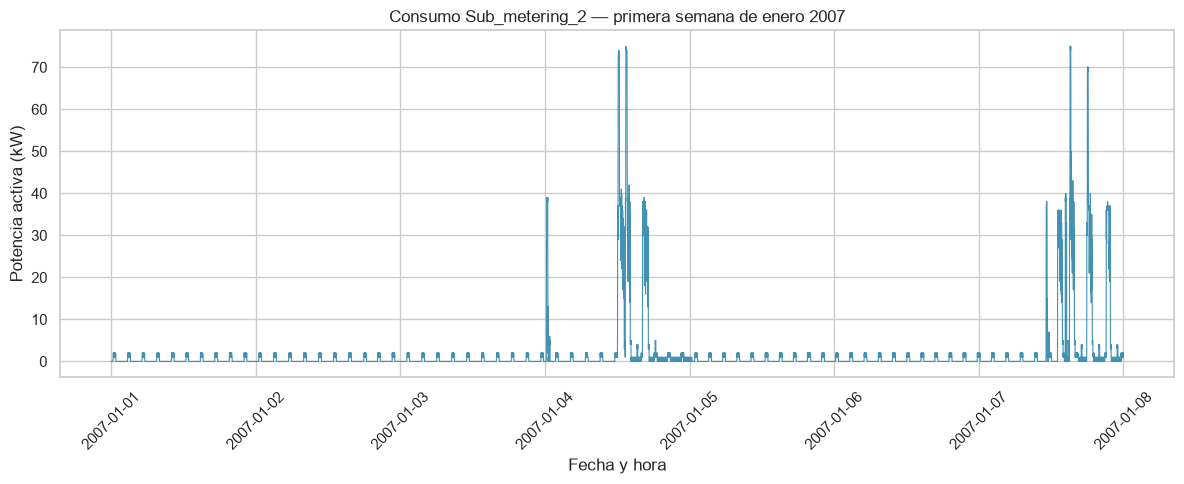

In [20]:
# Gráfico 1 — Consumo activo a lo largo del tiempo (muestra 1 semana)
semana = df['Sub_metering_2']['2007-01-01':'2007-01-07']

fig, ax = plt.subplots()
ax.plot(semana, color='#2E86AB', linewidth=0.8, alpha=0.9)
ax.set_title('Consumo Sub_metering_2 — primera semana de enero 2007')
ax.set_xlabel('Fecha y hora')
ax.set_ylabel('Potencia activa (kW)')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

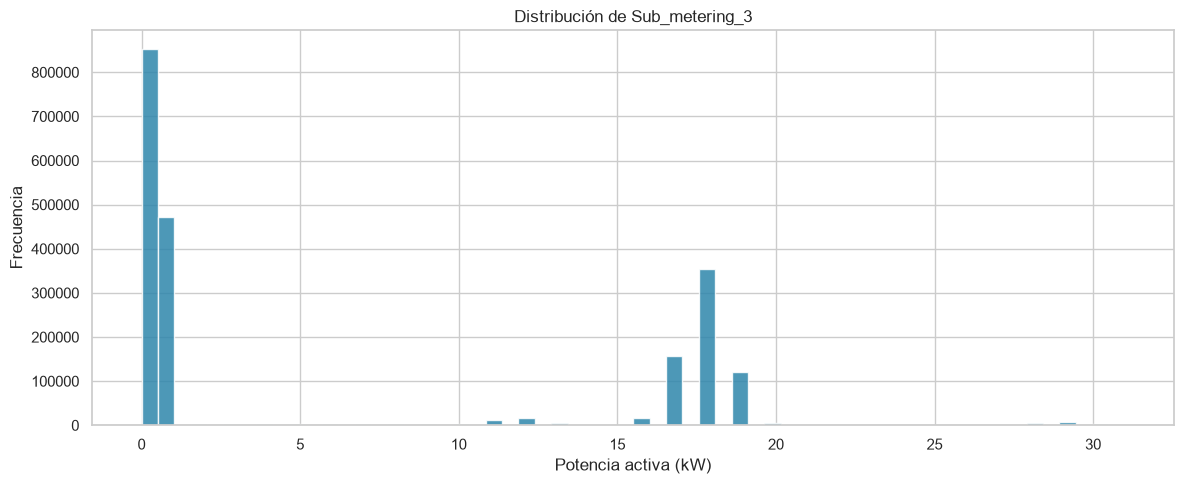

In [21]:
# Gráfico 2 — Distribución del consumo (histograma)
fig, ax = plt.subplots()
ax.hist(df['Sub_metering_3'].dropna(),
        bins=60, color='#2E86AB', edgecolor='white', alpha=0.85)
ax.set_title('Distribución de Sub_metering_3')
ax.set_xlabel('Potencia activa (kW)')
ax.set_ylabel('Frecuencia')
plt.tight_layout()
plt.show()

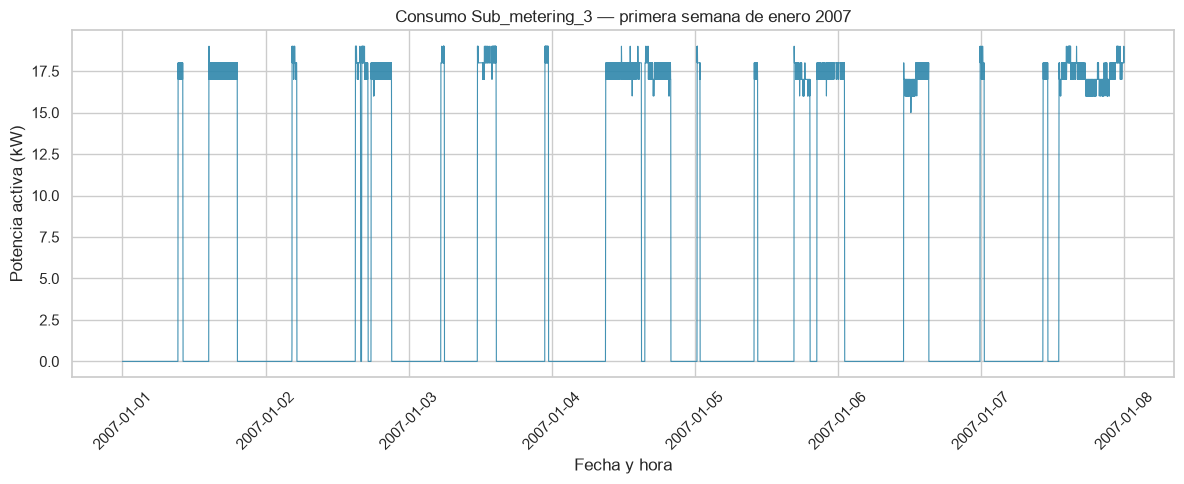

In [22]:
# Gráfico 1 — Consumo activo a lo largo del tiempo (muestra 1 semana)
semana = df['Sub_metering_3']['2007-01-01':'2007-01-07']

fig, ax = plt.subplots()
ax.plot(semana, color='#2E86AB', linewidth=0.8, alpha=0.9)
ax.set_title('Consumo Sub_metering_3 — primera semana de enero 2007')
ax.set_xlabel('Fecha y hora')
ax.set_ylabel('Potencia activa (kW)')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

5. **Seaborn — estadística visual con menos código**

Seaborn está diseñado para gráficos estadísticos. Con menos líneas de código obtienes más información.

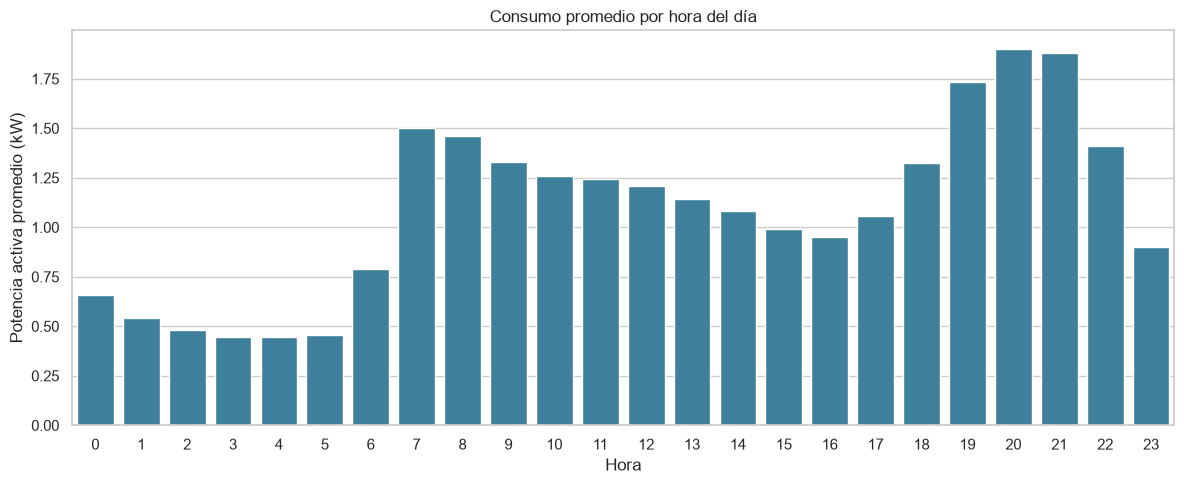

In [23]:
# Gráfico 3 — Consumo promedio por hora del día
df['hora'] = df.index.hour
consumo_por_hora = df.groupby('hora')['Global_active_power'].mean().reset_index()

fig, ax = plt.subplots()
sns.barplot(data=consumo_por_hora,
            x='hora', y='Global_active_power',
            color='#2E86AB', ax=ax)
ax.set_title('Consumo promedio por hora del día')
ax.set_xlabel('Hora')
ax.set_ylabel('Potencia activa promedio (kW)')
plt.tight_layout()
plt.show()

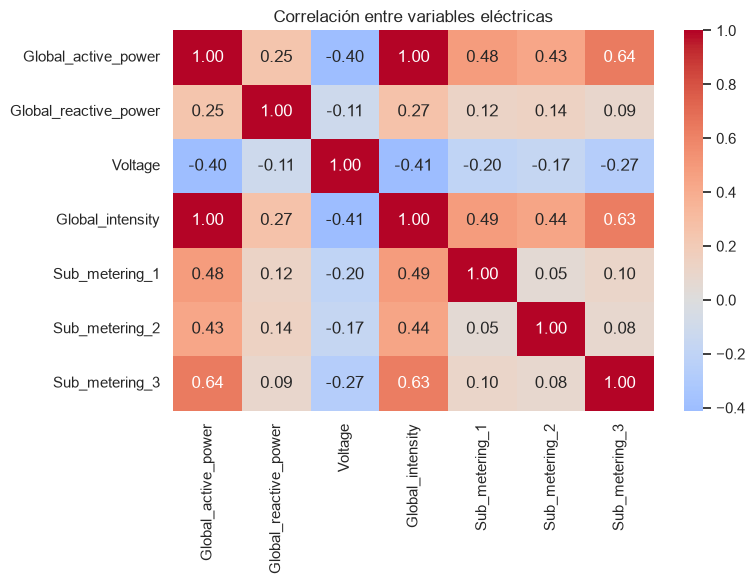

In [24]:
# Gráfico 4 — Correlación entre variables (heatmap)
fig, ax = plt.subplots(figsize=(8, 6))
correlacion = df[cols].corr()
sns.heatmap(correlacion,
            annot=True,        # muestra los números
            fmt='.2f',         # 2 decimales
            cmap='coolwarm',   # azul=negativo, rojo=positivo
            center=0,
            ax=ax)
ax.set_title('Correlación entre variables eléctricas')
plt.tight_layout()
plt.show()

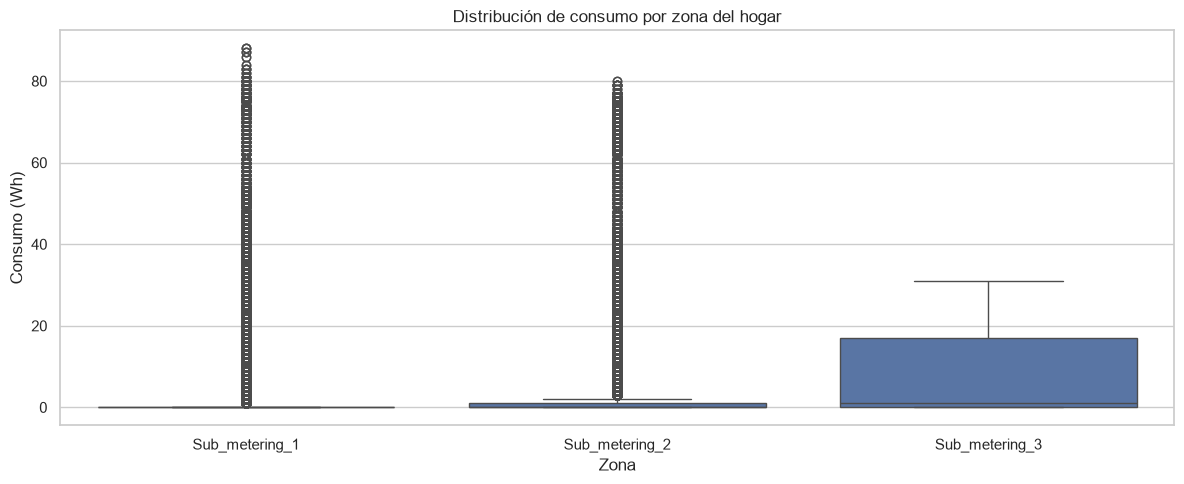

In [25]:
# Gráfico 5 — Comparación de submedidores (boxplot)
sub = df[['Sub_metering_1', 'Sub_metering_2', 'Sub_metering_3']].copy()
sub_melted = sub.melt(var_name='Zona', value_name='Consumo_Wh')

fig, ax = plt.subplots()
sns.boxplot(data=sub_melted, x='Zona', y='Consumo_Wh', ax=ax, legend=False)
ax.set_title('Distribución de consumo por zona del hogar')
ax.set_xlabel('Zona')
ax.set_ylabel('Consumo (Wh)')
plt.tight_layout()
plt.show()

6. Tu ejercicio práctico

Con lo que tienes hasta aquí, construye estos dos gráficos adicionales por tu cuenta:

Ejercicio A: Consumo promedio por día de la semana. Pista: df.index.dayofweek te da el número del día (0=lunes, 6=domingo). Usa un barplot de Seaborn.

Ejercicio B: Serie temporal del voltaje durante el mes de febrero 2007 (df['Voltage']['2007-02']). Usa ax.plot() de Matplotlib. Observa: ¿el voltaje es estable o fluctúa mucho?

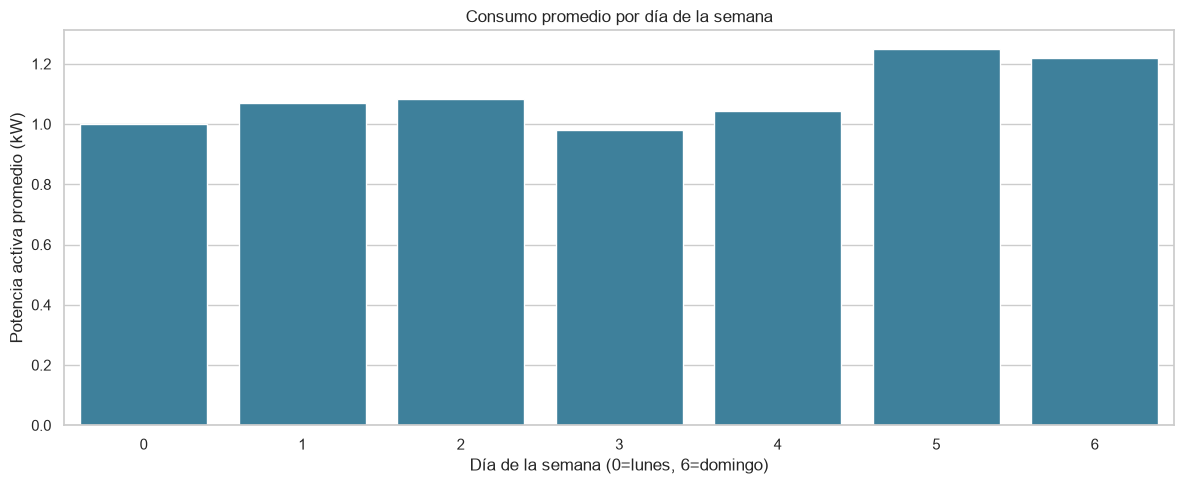

In [26]:
# Gráfico 3 — Consumo promedio por hora del día
df['día'] = df.index.dayofweek  # Cambié a dayofweek para ver el consumo por día de la semana
consumo_por_dia = df.groupby('día')['Global_active_power'].mean().reset_index()

fig, ax = plt.subplots()
sns.barplot(data=consumo_por_dia,
            x='día', y='Global_active_power',
            color='#2E86AB', ax=ax)
ax.set_title('Consumo promedio por día de la semana')
ax.set_xlabel('Día de la semana (0=lunes, 6=domingo)')
ax.set_ylabel('Potencia activa promedio (kW)')
plt.tight_layout()
plt.show()

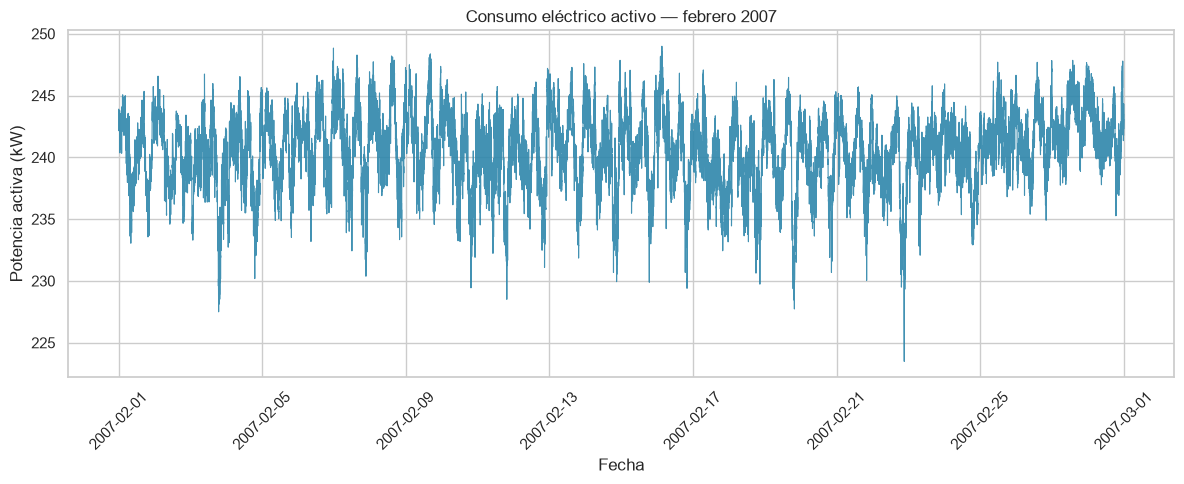

In [27]:
# Gráfico 1 — Consumo activo a lo largo del tiempo (muestra 1 semana)
mes = df['Voltage']['2007-02']

fig, ax = plt.subplots()
ax.plot(mes, color='#2E86AB', linewidth=0.8, alpha=0.9)
ax.set_title('Consumo eléctrico activo — febrero 2007')
ax.set_xlabel('Fecha')
ax.set_ylabel('Potencia activa (kW)')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

El comportamiento del voltaje tiene una forma sinusoidal de alta frecuencia lo que corresponde a la realidad porque las mediciones del dataset son de parámetros eléctricos de un hogar el cual se alimenta con corriente alterna.
Además, se notan cinco valles con voltajes menores a 230 y uno con voltaje menor a 225, lo cual no es una caída considerable pero sí se aleja del rango usual en el cual se encuentra el voltaje: 230 - 250 V.